# 合并图：降水异常空间分布 + wa垂直剖面

本笔记本仅包含两幅图的代码：
1. 三个实验(CNTL, P4K, 4×CO₂) Day+0的降水异常空间分布
2. 三个实验的wa经度-层高度剖面图（带风场箭头）

In [1]:
# 导入必要的库
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import os,sys
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.easyxp import simple_quiver_legend
import cmaps
from matplotlib.colors import LinearSegmentedColormap
# 复制所有用到的数据到目标目录

import shutil
# 配置参数
COMPOSITE_DIR = "/work/mh1498/m301257/cache/kelvin_wave/detected_events/pr_composites"
fig_save_path = os.path.join('/work/mh1498/m301257/fig') 
os.makedirs(fig_save_path, exist_ok=True)
TARGET_DIR = "/work/mh1498/m301257/Plot_data/fig07"

os.makedirs(TARGET_DIR, exist_ok=True)
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']


In [2]:
# 更新配置参数，使用fig07目录下的数据
COMPOSITE_DIR = "/work/mh1498/m301257/Plot_data/fig07/"
WA_COMPOSITE_DIR = "/work/mh1498/m301257/Plot_data/fig07/"
ZG_DATA_DIR = "/work/mh1498/m301257/Plot_data/fig07/"
MASK_DATA_DIR = "/work/mh1498/m301257/Plot_data/fig07/"
FIG_SAVE_DIR = "/work/mh1498/m301257/fig"

os.makedirs(FIG_SAVE_DIR, exist_ok=True)

EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

print("✅ 路径配置完成")
print(f"📁 降水数据目录: {COMPOSITE_DIR}")
print(f"📁 wa/ua数据目录: {WA_COMPOSITE_DIR}")
print(f"📁 zg数据目录: {ZG_DATA_DIR}")
print(f"📁 ocean mask目录: {MASK_DATA_DIR}")
print(f"📁 图片保存目录: {FIG_SAVE_DIR}")

✅ 路径配置完成
📁 降水数据目录: /work/mh1498/m301257/Plot_data/fig07/
📁 wa/ua数据目录: /work/mh1498/m301257/Plot_data/fig07/
📁 zg数据目录: /work/mh1498/m301257/Plot_data/fig07/
📁 ocean mask目录: /work/mh1498/m301257/Plot_data/fig07/
📁 图片保存目录: /work/mh1498/m301257/fig


## 1. 加载数据

In [3]:
# 加载降水复合数据
print("\n📂 加载降水复合数据...")
pr_composites = {}
for exp in EXPERIMENTS:
    file_path = os.path.join(COMPOSITE_DIR, f'pr_composite_{exp.lower()}.nc')
    if os.path.exists(file_path):
        pr_composites[exp] = xr.open_dataarray(file_path)
        print(f"  ✅ {exp}: {pr_composites[exp].shape}")
    else:
        print(f"  ❌ {exp}: 文件未找到 - {file_path}")

print(f"\n✅ 已加载 {len(pr_composites)} 个实验的降水数据")


📂 加载降水复合数据...
  ✅ CNTL: (9, 15, 180)
  ✅ P4K: (9, 15, 180)
  ✅ 4CO2: (9, 15, 180)

✅ 已加载 3 个实验的降水数据
  ✅ CNTL: (9, 15, 180)
  ✅ P4K: (9, 15, 180)
  ✅ 4CO2: (9, 15, 180)

✅ 已加载 3 个实验的降水数据


In [4]:
def _ocean(ds):
    fraction = xr.open_dataset(os.path.join(MASK_DATA_DIR, "ocean_mask_2deg.nc"))['__xarray_dataarray_variable__']
    return fraction == 1
zg_ds = {
    'CNTL': xr.open_dataarray(os.path.join(ZG_DATA_DIR, 'zg_2deg_interp_cntl.nc')).where(_ocean).mean(['lat','lon']),
    'P4K': xr.open_dataarray(os.path.join(ZG_DATA_DIR, 'zg_2deg_interp_p4k.nc')).where(_ocean).mean(['lat','lon']),
    '4CO2': xr.open_dataarray(os.path.join(ZG_DATA_DIR, 'zg_2deg_interp_4co2.nc')).where(_ocean).mean(['lat','lon']),
    
}

In [5]:
# 加载wa、ua和va复合数据
print("\n📂 加载wa、ua和va复合数据...")

# 使用fig07目录下的数据
wa_composites = {}
ua_composites = {}
va_composites = {}

for exp in EXPERIMENTS:
    # 加载wa
    print(f"Checking directory: {WA_COMPOSITE_DIR} for wa {exp}")
    wa_file = os.path.join(WA_COMPOSITE_DIR, f'wa_composite_levALL_{exp.lower()}.nc')
    if os.path.exists(wa_file):
        wa_data = xr.open_dataarray(wa_file)
        zg_data = zg_ds[exp]
        print(f"Loaded zg_data for {exp}: {zg_data.shape}")
        # 标准化维度名称
        if 'level' in wa_data.dims:
            wa_data = wa_data.rename({'level': 'lev'})
            wa_data = wa_data.assign_coords(lev=zg_data.values)
        wa_composites[exp] = wa_data
        print(f"  ✅ wa {exp}: {wa_data.shape}")
    
    # 加载ua
    ua_file = os.path.join(WA_COMPOSITE_DIR, f'ua_composite_levALL_{exp.lower()}.nc')
    if os.path.exists(ua_file):
        ua_data = xr.open_dataarray(ua_file)
        
        # 标准化维度名称
        if 'level' in ua_data.dims:
            ua_data = ua_data.rename({'level': 'lev'})
            ua_data = ua_data.assign_coords(lev=zg_data.values)
        ua_composites[exp] = ua_data
        print(f"  ✅ ua {exp}: {ua_data.shape}")
    
    # 加载va
    va_file = os.path.join(WA_COMPOSITE_DIR, f'va_composite_levALL_{exp.lower()}.nc')
    if os.path.exists(va_file):
        va_data = xr.open_dataarray(va_file)
        
        # 标准化维度名称
        if 'level' in va_data.dims:
            va_data = va_data.rename({'level': 'lev'})
            va_data = va_data.assign_coords(lev=zg_data.values)
        va_composites[exp] = va_data
        print(f"  ✅ va {exp}: {va_data.shape}")

print(f"\n✅ 已加载 {len(wa_composites)} 个实验的wa数据")
print(f"✅ 已加载 {len(ua_composites)} 个实验的ua数据")
print(f"✅ 已加载 {len(va_composites)} 个实验的va数据")


📂 加载wa、ua和va复合数据...
Checking directory: /work/mh1498/m301257/Plot_data/fig07/ for wa CNTL
Loaded zg_data for CNTL: (22,)
  ✅ wa CNTL: (22, 9, 15, 180)
  ✅ ua CNTL: (22, 9, 15, 180)
  ✅ va CNTL: (22, 9, 15, 180)
Checking directory: /work/mh1498/m301257/Plot_data/fig07/ for wa P4K
Loaded zg_data for P4K: (22,)
  ✅ wa P4K: (22, 9, 15, 180)
  ✅ ua P4K: (22, 9, 15, 180)
  ✅ va P4K: (22, 9, 15, 180)
Checking directory: /work/mh1498/m301257/Plot_data/fig07/ for wa 4CO2
Loaded zg_data for 4CO2: (22,)
  ✅ wa 4CO2: (22, 9, 15, 180)
  ✅ ua 4CO2: (22, 9, 15, 180)
  ✅ va 4CO2: (22, 9, 15, 180)

✅ 已加载 3 个实验的wa数据
✅ 已加载 3 个实验的ua数据
✅ 已加载 3 个实验的va数据
Loaded zg_data for 4CO2: (22,)
  ✅ wa 4CO2: (22, 9, 15, 180)
  ✅ ua 4CO2: (22, 9, 15, 180)
  ✅ va 4CO2: (22, 9, 15, 180)

✅ 已加载 3 个实验的wa数据
✅ 已加载 3 个实验的ua数据
✅ 已加载 3 个实验的va数据


## 3. 图2：wa经度-层高度剖面（带风场箭头）


🎨 绘制wa经度-层高度剖面图...
  ✅ CNTL: 选择了 19 个高度层 (206-19539 米)
  ✅ P4K: 选择了 19 个高度层 (206-19539 米)
  ✅ 4CO2: 选择了 19 个高度层 (206-19539 米)


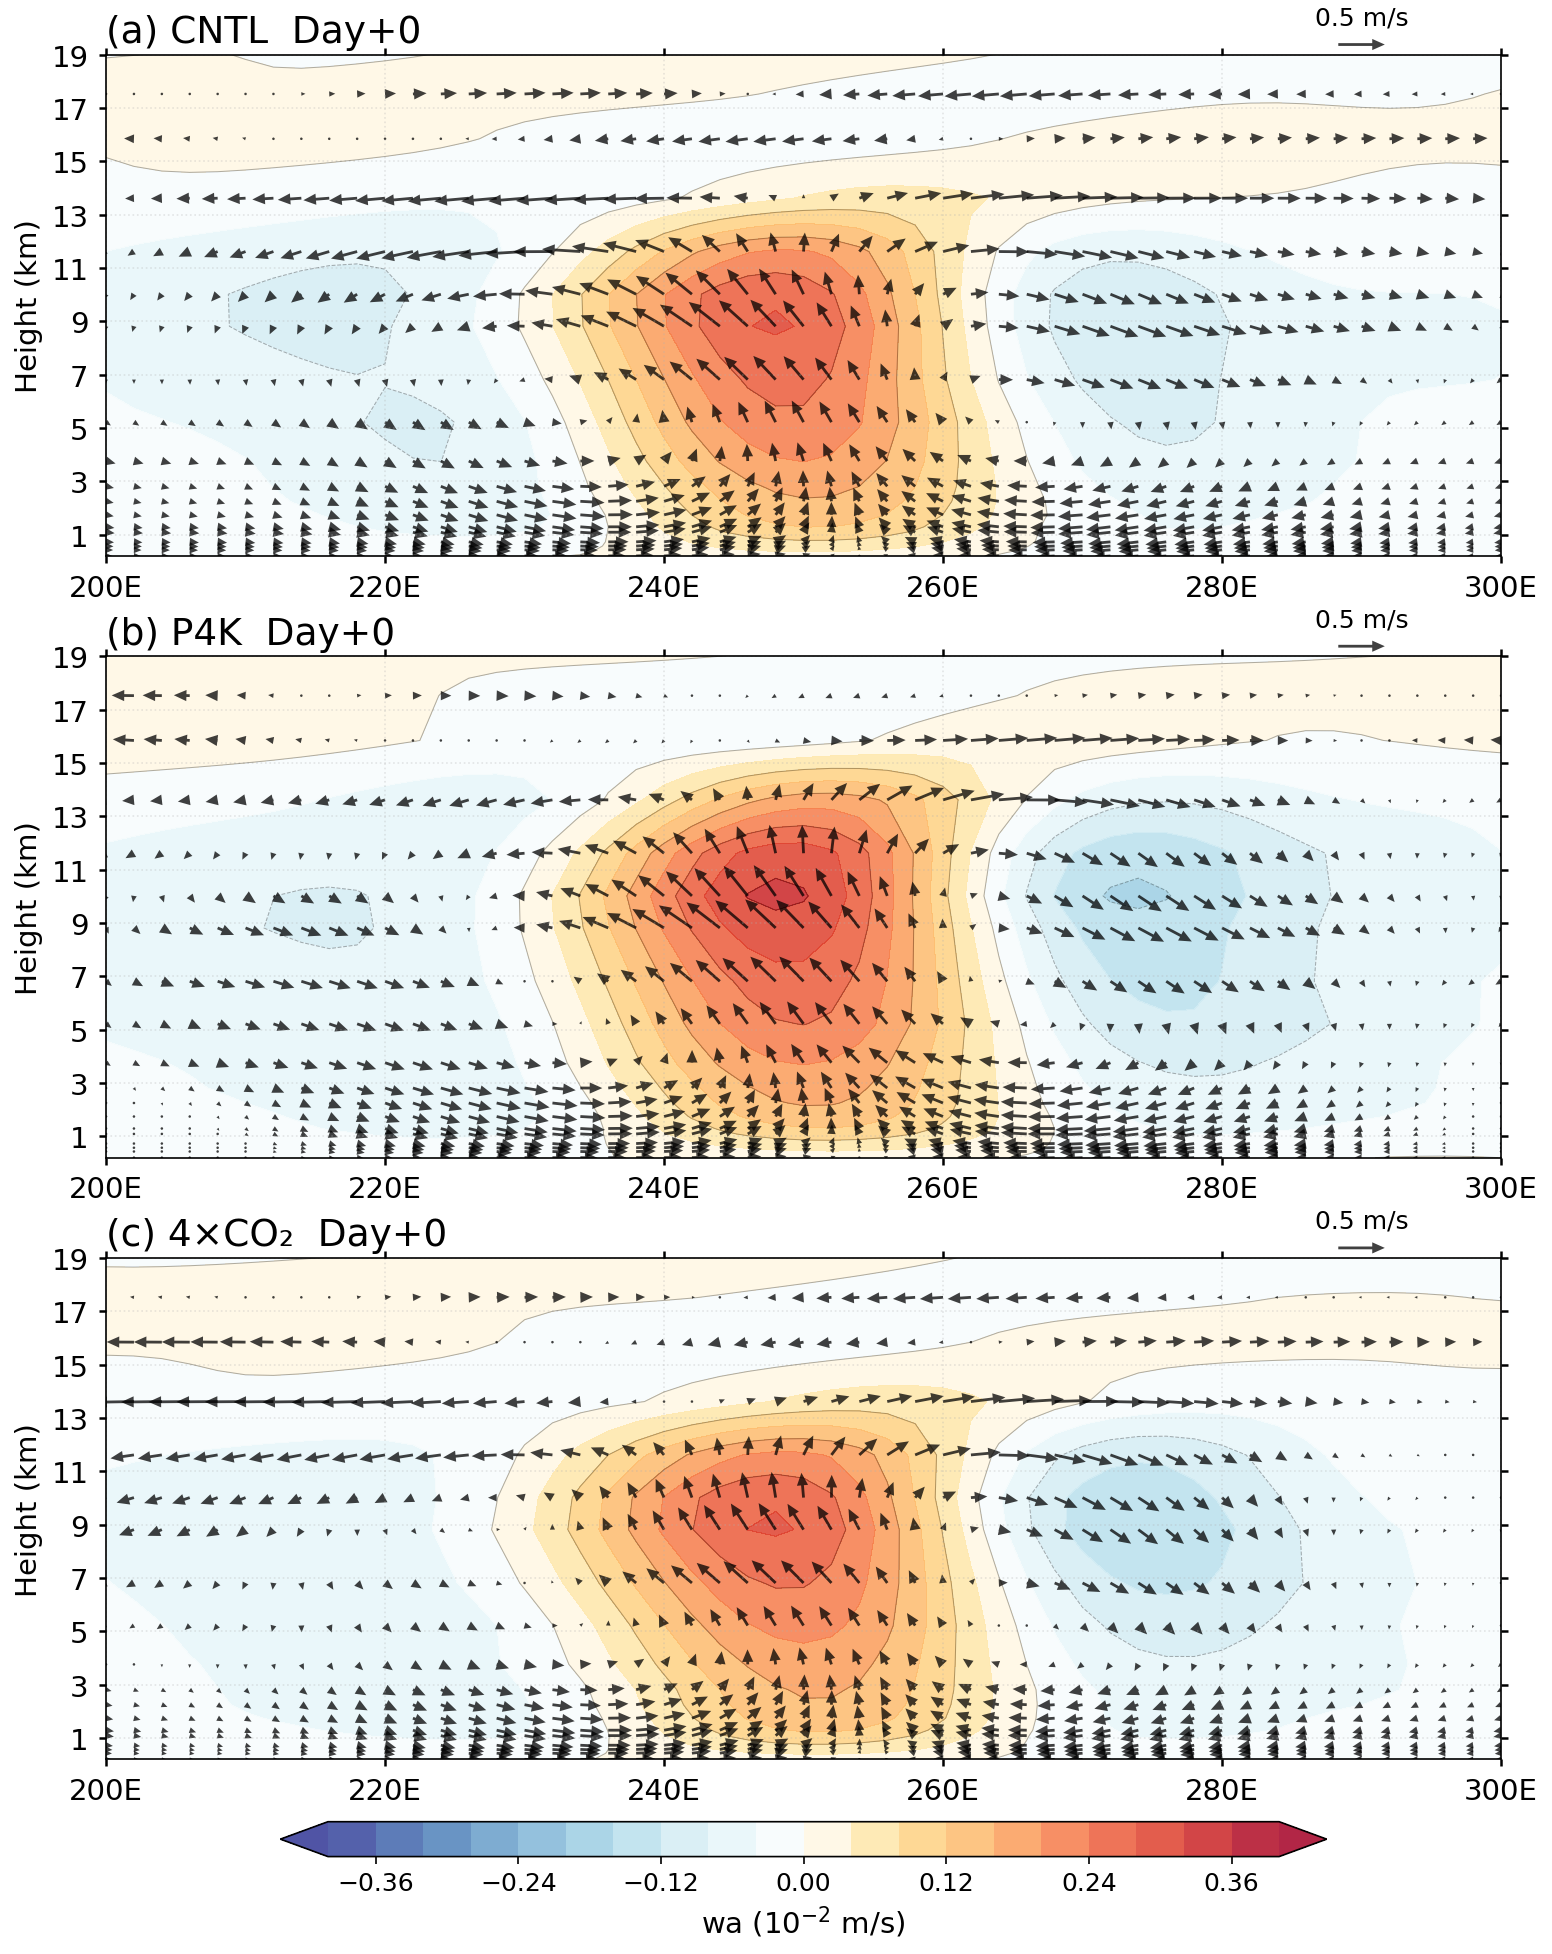

In [7]:
def plot_lon_level_section_with_arrows(
        wa_composites, ua_composites,
        experiments=['CNTL', 'P4K', '4CO2'],
        lag=0, lat_range=(5, 15), lon_range=(200, 300),
        arrow_density=1, figsize=(12, 18),
        wind_scale=15, arrow_width=0.002,
        height_range=None):  # 高度范围，单位：米，None表示使用全部数据
    """
    绘制经度-高度剖面图，带有风场箭头
    
    参数:
    height_range: tuple or None, 高度范围（米），None表示使用全部高度
    """
    from matplotlib.colors import LinearSegmentedColormap
    
    titles = ['(a) CNTL', '(b) P4K', '(c) 4×CO₂']
    fig, axes = plt.subplots(len(experiments), 1, figsize=figsize, dpi=150)
    
    if len(experiments) == 1:
        axes = [axes]
    
    for i, exp in enumerate(experiments):
        ax = axes[i]
        
        if exp not in wa_composites or exp not in ua_composites:
            print(f"  ⚠️ {exp} 数据未找到")
            continue
        
        wa_da = wa_composites[exp]
        ua_da = ua_composites[exp]
        
        # 自动识别垂直维度名
        if 'level' in wa_da.dims:
            wa_level_dim = 'level'
        elif 'lev' in wa_da.dims:
            wa_level_dim = 'lev'
        else:
            print(f"  ⚠️ {exp}: 未找到垂直维度")
            continue
        
        if 'level' in ua_da.dims:
            ua_level_dim = 'level'
        elif 'lev' in ua_da.dims:
            ua_level_dim = 'lev'
        else:
            print(f"  ⚠️ {exp}: 未找到垂直维度")
            continue
        
        # 数据选择：lag, lat, lon
        wa_data = (
            wa_da
            .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
            .mean(dim='lat')
        )
        
        ua_data = (
            ua_da
            .sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
            .mean(dim='lat')
        )
        
        # 如果指定了高度范围，进行筛选
        if height_range is not None:
            # 获取高度坐标
            heights = wa_data[wa_level_dim].values
            # 找到在指定范围内的索引
            mask = (heights >= height_range[0]) & (heights <= height_range[1])
            if mask.sum() == 0:
                print(f"  ⚠️ {exp}: 指定的高度范围内没有数据")
                print(f"     高度范围: {height_range[0]}-{height_range[1]} 米")
                print(f"     可用高度范围: {heights.min():.0f} - {heights.max():.0f} 米")
                continue
            # 使用布尔索引选择数据
            wa_data = wa_data.isel({wa_level_dim: mask})
            ua_data = ua_data.isel({ua_level_dim: mask})
            print(f"  ✅ {exp}: 选择了 {mask.sum()} 个高度层 ({wa_data[wa_level_dim].min().values:.0f}-{wa_data[wa_level_dim].max().values:.0f} 米)")
        
        # 检查数据是否为空
        if wa_data.sizes[wa_level_dim] == 0:
            print(f"  ⚠️ {exp}: 没有可用数据")
            continue
        
        # 单位处理：wa从Pa/s转为10^-2 m/s
        wa_plot = wa_data * 100
        
        # 坐标准备 - 使用实际高度值（单位：米，转换为千米）
        lon_vals = wa_data.lon.values
        level_vals = wa_data[wa_level_dim].values  # 实际高度值（米）
        height_km = level_vals / 1000.0  # 转换为千米
        LON, HEIGHT = np.meshgrid(lon_vals, height_km)
        
        # colormap
        colors_list = [
            '#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
            'white',
            '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026'
        ]
        cmap = LinearSegmentedColormap.from_list('wa_cmap', colors_list)
        
        levels = np.linspace(-0.4, 0.4, 21)
        
        # 绘制填色图
        cf = ax.contourf(LON, HEIGHT, wa_plot.values, levels, cmap=cmap, alpha=0.85, extend='both')
        
        # 绘制等值线
        ax.contour(LON, HEIGHT, wa_plot.values, levels[::2], colors='k', alpha=0.3, linewidths=0.5)
        
        # 风场箭头
        LON_q = LON[::arrow_density, ::arrow_density]
        HEIGHT_q = HEIGHT[::arrow_density, ::arrow_density]
        UA_q = ua_data.values[::arrow_density, ::arrow_density]
        WA_q = wa_plot.values[::arrow_density, ::arrow_density]
        
        Q = ax.quiver(
            LON_q, HEIGHT_q,
            UA_q, WA_q,
            scale=wind_scale,
            width=arrow_width,
            headwidth=4, headlength=4.5,
            color='k', alpha=0.75
        )
        
        ax.quiverkey(Q, 0.9, 1.02, 0.5, "0.5 m/s", coordinates='axes', fontproperties={'size': 12})
        
        # y轴：高度（千米）- 从低到高
        ax.set_ylim(height_km.min(),15)
        # 不反转y轴，让高度从下到上递增
        # 设置合理的y轴刻度（例如每2km一个刻度）
        height_min = int(np.ceil(height_km.min()))
        height_max = int(np.floor(height_km.max()))
        yticks = np.arange(height_min, height_max+1, 2)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{int(h)}" for h in yticks])
        ax.set_ylabel('Height (km)', fontsize=14)
        
        # x轴：经度格式化
        def east_longitude_formatter(x, pos):
            val = x % 360
            return f"{int(val)}E"
        
        ax.xaxis.set_major_formatter(east_longitude_formatter)
        ax.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
        
        # 标题
        ax.set_title(f"{titles[i]}  Day{lag:+d}", loc='left', fontsize=18)
        ax.grid(True, linestyle=':', alpha=0.3)
        
        # 刻度参数
        ax.tick_params(which='both', direction='out', width=1.2,
                      pad=5, labelsize=14,
                      bottom=True, left=True, right=True, top=True)
        
        # colorbar
        if i == len(experiments)-1:
            cbar = plt.colorbar(cf, ax=axes, orientation='horizontal', 
                               pad=0.03, aspect=30, shrink=0.75)
            cbar.set_label(r"wa ($10^{-2}$ m/s)", fontsize=14)
            cbar.ax.tick_params(labelsize=12)



    return fig

# 绘制wa垂直剖面图
print("\n🎨 绘制wa经度-层高度剖面图...")
fig2 = plot_lon_level_section_with_arrows(
    wa_composites=wa_composites,
    ua_composites=ua_composites,
    experiments=['CNTL', 'P4K', '4CO2'],
    lag=0,
    lat_range=(5, 15),
    lon_range=(200, 300),
    arrow_density=1,
    figsize=(12, 18),
    wind_scale=15,
    height_range=(100, 20000)  # 100米-20km高度范围，避免地表数据
)
plt.show()

## 4. 合并到一张图（可选）

如果需要将两幅图合并到一张图上，可以使用以下代码


🎨 绘制合并图...
💾 合并图已保存: /work/mh1498/m301257/fig/fig07.png
💾 合并图已保存: /work/mh1498/m301257/fig/fig07.png


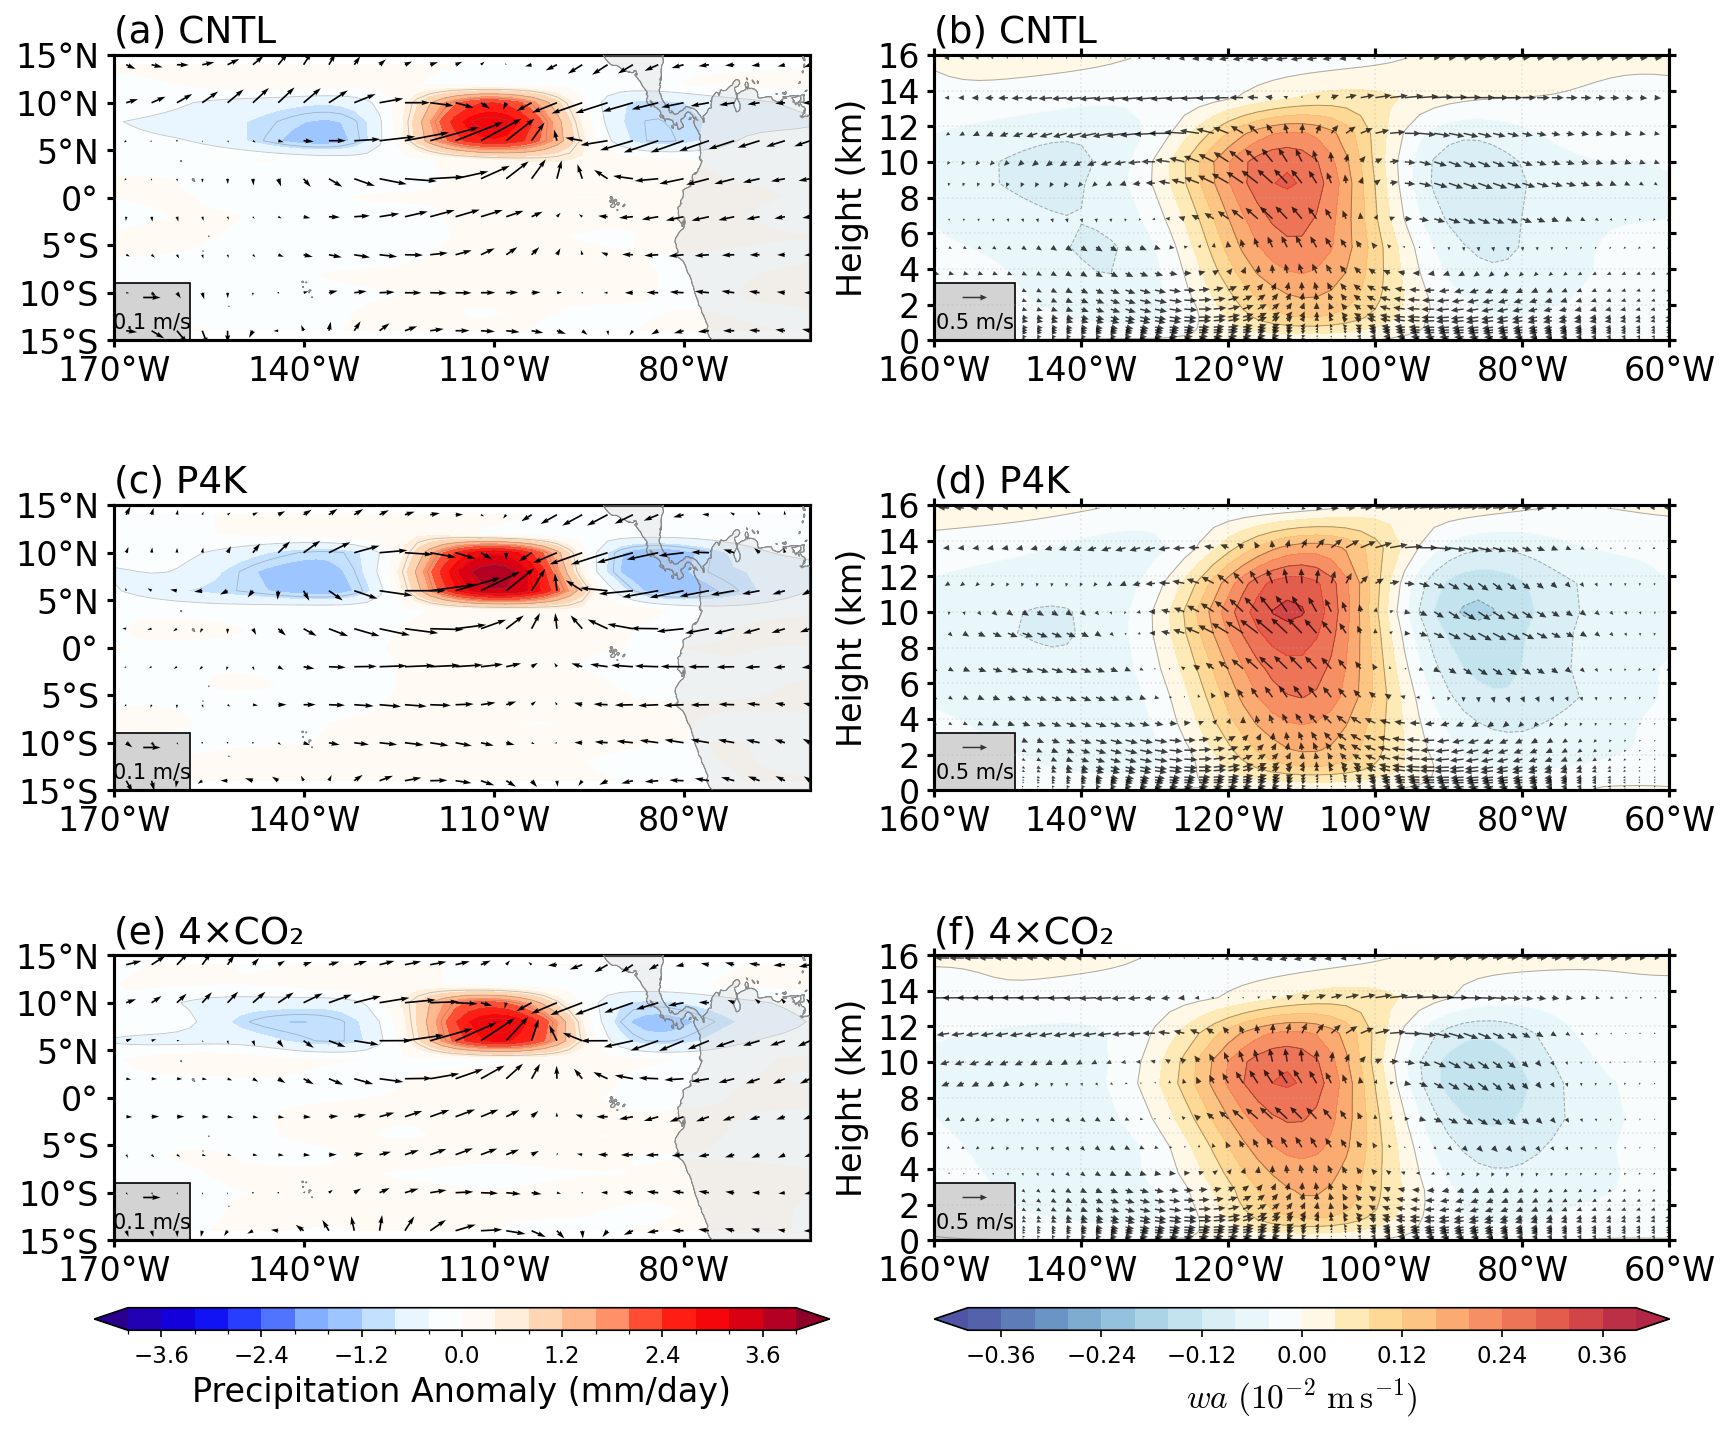

In [ ]:
def plot_combined_figure(
        pr_composites, wa_composites, ua_composites, va_composites,
        experiments=['CNTL', 'P4K', '4CO2'],
        lag=0, lat_range=(5, 15), lon_range=(200, 300),
        figsize=(20, 18), height_range=(0, 20000)):
    """
    将降水空间分布和wa垂直剖面合并到一张图上（2列3行布局）
    左列：降水水平空间分布（带水平风场箭头）
    右列：wa垂直剖面
    使用add_axes确保子图大小比例一致
    
    参数:
    height_range: tuple, 高度范围（米），默认 (0, 20000) 即 0-20km
    """
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib as mpl

    mpl.rcParams['mathtext.fontset'] = 'cm'


    def east_longitude_formatter(x, pos):
        val = x % 360
        return rf"{int(val)}$^\circ$E"

    
    fig = plt.figure(figsize=figsize, dpi=150)
    
    # 定义子图的位置和大小 [left, bottom, width, height]
    # 左列（降水空间分布）- 带投影，高度稍大
    left_col = 0.1
    plot_width_pr = 0.35
    plot_height_pr = 0.19
    
    # 右列（wa垂直剖面）- 非投影，高度稍小以匹配视觉效果
    right_col = 0.5
    plot_width_wa = 0.35
    plot_height_wa = 0.19 # 降低高度使视觉上与左侧投影图一致
    
    # 三行的bottom位置（右列需要向上调整一些以保持对齐）
    row_bottoms_pr = [0.68, 0.38, 0.08]
    row_bottoms_wa = [0.68, 0.38, 0.08]  # 右列向上偏移0.025
    
    # 标题 - 使用a-f的序号
    pr_titles = ['(a) CNTL', '(c) P4K', '(e) 4×CO₂']
    wa_titles = ['(b) CNTL', '(d) P4K', '(f) 4×CO₂']
    
    # 左侧：降水空间分布
    newcmp = cmaps.NCV_blu_red
    colors_blue = [newcmp[i].colors for i in [5, 20, 35, 50, 65, 85, 95, 110, 125]]
    colors_red = [newcmp[i].colors for i in [135, 150, 165, 180, 200, 210, 220, 235, 250]]
    all_colors = colors_blue + [[1., 1., 1.]] + colors_red
    color_positions = np.linspace(0, 1, len(all_colors))
    pr_cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', 
                                                 list(zip(color_positions, all_colors)), N=256)
    
    pr_levels = np.linspace(-4., 4., 21)
    pr_contour_levels = np.arange(-10, 0, 0.6)
    pr_contour_levels = np.append(pr_contour_levels, np.arange(0.6, 10, 0.6))
    
    proj = ccrs.PlateCarree(central_longitude=210)
    
    # 用于保存axes对象
    pr_axes = []
    wa_axes = []
    
    for i, exp in enumerate(experiments):
        # ===== 左侧：降水空间分布（带水平风场） =====
        ax_pr = fig.add_axes([left_col, row_bottoms_pr[i], plot_width_pr, plot_height_pr], 
                            projection=proj)
        
        if exp in pr_composites:
            data_pr = pr_composites[exp].sel(lag=lag)
            
            ax_pr.coastlines(linewidth=0.5, alpha=0.6)
            ax_pr.set_xlim([-20, 90])
            ax_pr.set_ylim([-15, 15])
            ax_pr.set_xticks(np.arange(-20, 91, 30))
            ax_pr.set_yticks(np.arange(-15, 16, 5))
            ax_pr.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
            ax_pr.yaxis.set_major_formatter(LatitudeFormatter())
            
            cf_pr = data_pr.plot.contourf(ax=ax_pr, levels=pr_levels, cmap=pr_cmap,
                                         add_colorbar=False, transform=ccrs.PlateCarree(),
                                         extend='both', add_labels=False)
            
            ax_pr.add_feature(cfeature.LAND, facecolor='lightgray', zorder=4, alpha=0.3)
            ax_pr.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=3)
            ax_pr.spines[['right','left','top','bottom']].set_linewidth(1.5) 
            ax_pr.spines[['right','left','top','bottom']].set_color('black') 
            ax_pr.spines[:].set_visible(True)

            data_pr.plot.contour(ax=ax_pr, levels=pr_contour_levels, colors='dimgray',
                                alpha=0.4, linewidths=0.4, linestyles='solid',
                                add_labels=False, transform=ccrs.PlateCarree())
            
            # 添加水平风场箭头（850 hPa层）
            if exp in ua_composites and exp in va_composites:
                # 获取ua和va数据
                ua_wind = ua_composites[exp].sel(lag=lag)
                va_wind = va_composites[exp].sel(lag=lag)
                
                # 选择850 hPa层（或接近地表的层）
                # 假设lev坐标是高度（米），850hPa约1500米
                target_height = 1500  # 米
                ua_level_dim = 'lev' if 'lev' in ua_wind.dims else 'level'
                
                # 找到最接近目标高度的层
                heights = ua_wind[ua_level_dim].values
                closest_idx = np.argmin(np.abs(heights - target_height))
                
                ua_850 = ua_wind.isel({ua_level_dim: closest_idx})
                va_850 = va_wind.isel({ua_level_dim: closest_idx})
                
                # 降采样风场以避免箭头过密
                skip = 2  # 每2个格点取一个，增加箭头密度
                lons_wind = ua_850.lon.values[::skip]
                lats_wind = ua_850.lat.values[::skip]
                u_plot = ua_850.values[::skip, ::skip]
                v_plot = va_850.values[::skip, ::skip]
                
                # 绘制风场箭头（增大尺寸）
                Q_pr = ax_pr.quiver(
                    lons_wind, lats_wind, u_plot, v_plot,
                    transform=ccrs.PlateCarree(),
                    scale=4,  # 减小scale值使箭头更长
                    # width=0.002,  # 增加箭头宽度
                    # headwidth=2.5,  # 增大箭头头部宽度
                    # headlength=5,  # 增大箭头头部长度
                    color='black',
                    alpha=1,
                    zorder=4
                )
                
                # 使用simple_quiver_legend添加风场图例到右上角
                simple_quiver_legend(
                ax=ax_pr,
                quiver=Q_pr,
                reference_value=0.1,
                unit='m/s',
                font_size=10,
                text_offset=0.05,
                legend_location='lower left',
                zorder=12,
                box_height=0.2,
                box_facecolor='lightgray')
            
                ax_pr.set_title(f'{pr_titles[i]}', fontsize=18, loc='left')
                ax_pr.tick_params(labelsize=16,width=1.5)
                ax_pr.set_aspect(1.5)
        pr_axes.append(ax_pr)
        
        # ===== 右侧：wa垂直剖面 =====
        ax_wa = fig.add_axes([right_col, row_bottoms_wa[i], plot_width_wa, plot_height_wa])
        
        if exp in wa_composites and exp in ua_composites:
            wa_da = wa_composites[exp]
            ua_da = ua_composites[exp]
            
            wa_level_dim = 'lev' if 'lev' in wa_da.dims else 'level'
            ua_level_dim = 'lev' if 'lev' in ua_da.dims else 'level'
            
            # 先选择经纬度和lag
            wa_data = (wa_da.sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
                      .mean(dim='lat'))
            ua_data = (ua_da.sel(lag=lag, lat=slice(*lat_range), lon=slice(*lon_range))
                      .mean(dim='lat'))
            
            # 如果指定了高度范围，进行筛选
            if height_range is not None:
                heights = wa_data[wa_level_dim].values
                mask = (heights >= height_range[0]) & (heights <= height_range[1])
                if mask.sum() == 0:
                    print(f"  ⚠️ {exp}: 选择的高度范围内没有数据")
                    continue
                wa_data = wa_data.isel({wa_level_dim: mask})
                ua_data = ua_data.isel({ua_level_dim: mask})
            
            # 检查数据是否为空
            if wa_data.sizes[wa_level_dim] == 0:
                print(f"  ⚠️ {exp}: 没有可用数据")
                continue
            
            wa_plot = wa_data * 100
            
            lon_vals = wa_data.lon.values
            level_vals = wa_data[wa_level_dim].values  # 实际高度值（米）
            height_km = level_vals / 1000.0  # 转换为千米
            LON, HEIGHT = np.meshgrid(lon_vals, height_km)
            
            colors_list = ['#313695', '#4575b4', '#74add1', '#abd9e9', '#e0f3f8',
                          'white', '#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']
            wa_cmap = LinearSegmentedColormap.from_list('wa_cmap', colors_list)
            wa_levels = np.linspace(-0.4, 0.4, 21)
            
            cf_wa = ax_wa.contourf(LON, HEIGHT, wa_plot.values, wa_levels, 
                                   cmap=wa_cmap, alpha=0.85, extend='both')
            ax_wa.contour(LON, HEIGHT, wa_plot.values, wa_levels[::2], 
                         colors='k', alpha=0.3, linewidths=0.5)
            
            LON_q = LON[::1, ::1]
            HEIGHT_q = HEIGHT[::1, ::1]
            UA_q = ua_data.values[::1, ::1]
            WA_q = wa_plot.values[::1, ::1]
            
            Q = ax_wa.quiver(LON_q, HEIGHT_q, UA_q, WA_q, scale=15, width=0.002,
                            headwidth=4, headlength=4.5, color='k', alpha=0.75)
 
            simple_quiver_legend( ax=ax_wa,
                quiver=Q,
                reference_value=0.5,
                unit='m/s',
                font_size=10,
                text_offset=0.05,
                legend_location='lower left',
                box_height=0.2,
                box_facecolor='lightgray')
            # y轴：固定显示0-15km的高度范围
            ax_wa.set_ylim(0, 16)
            # 设置y轴刻度（每2km一个刻度）
            yticks = np.arange(0, 17, 2)
            ax_wa.set_yticks(yticks)
            ax_wa.set_yticklabels([f"{int(h)}" for h in yticks])
            ax_wa.set_ylabel('Height (km)', fontsize=16)
            

            ax_wa.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
            ax_wa.spines[['right','left','top','bottom']].set_linewidth(1.5) 
            # ax_wa.spines[['right','left','top','bottom']].set_color('black') 
            
            ax_wa.set_xticks(np.arange(lon_range[0], lon_range[1]+1, 20))
            ax_wa.set_title(f'{wa_titles[i]}', fontsize=18, loc='left')
            ax_wa.grid(True, linestyle=':', alpha=0.3)
            ax_wa.tick_params(which='both', direction='out', width=1.5, labelsize=16,
                             bottom=True, left=True, right=True, top=True)
           
        wa_axes.append(ax_wa)
    
    # 添加colorbar（分别为左列和右列添加）
    # 左列降水的colorbar
    cbar_ax_pr = fig.add_axes([left_col, 0.02, plot_width_pr, 0.015])
    cbar_pr = fig.colorbar(cf_pr, cax=cbar_ax_pr, orientation='horizontal',shrink=0.75)
    cbar_pr.set_label('Precipitation Anomaly (mm/day)', fontsize=16)
    cbar_pr.ax.tick_params(labelsize=11)
    
    # 右列wa的colorbar
    cbar_ax_wa = fig.add_axes([right_col, 0.02, plot_width_wa, 0.015])
    cbar_wa = fig.colorbar(cf_wa, cax=cbar_ax_wa, orientation='horizontal',shrink=0.75)
    cbar_wa.set_label(r"$wa\ \mathrm{(10^{-2}}\ \mathrm{m\,s^{-1}})$", fontsize=16)

    cbar_wa.ax.tick_params(labelsize=11)
    

    save_path = os.path.join(FIG_SAVE_DIR, "fig07.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"💾 合并图已保存: {save_path}")
    
    return fig

# 绘制合并图
print("\n🎨 绘制合并图...")
fig_combined = plot_combined_figure(
    pr_composites=pr_composites,
    wa_composites=wa_composites,
    ua_composites=ua_composites,
    va_composites=va_composites,
    experiments=['CNTL', 'P4K', '4CO2'],
    lag=0,
    lat_range=(5, 15),
    lon_range=(200, 300),
    figsize=(14, 10),
    height_range=(0, 16000)  # 100米-15km高度范围
)
plt.show()

In [9]:
# 检查左侧降水图中实际选择的风场高度层
print("\n🔍 检查水平风场的实际高度层：")
print("="*60)

target_height = 1500  # 米（代码中设置的目标高度）

for exp in ['CNTL', 'P4K', '4CO2']:
    if exp in ua_composites:
        ua_wind = ua_composites[exp].sel(lag=0)
        ua_level_dim = 'lev' if 'lev' in ua_wind.dims else 'level'
        heights = ua_wind[ua_level_dim].values
        
        # 找到最接近目标高度的层
        closest_idx = np.argmin(np.abs(heights - target_height))
        actual_height = heights[closest_idx]
        
        print(f"\n{exp}:")
        print(f"  目标高度: {target_height} m ({target_height/1000:.2f} km)")
        print(f"  实际选择: {actual_height:.1f} m ({actual_height/1000:.2f} km)")
        print(f"  差异: {abs(actual_height - target_height):.1f} m")

print("\n" + "="*60)
print("\n📝 建议的图例描述：")
print("\n【中文】")
print("图X. 三个实验（CNTL、P4K、4×CO₂）在Kelvin波Day 0的复合结果。")
print("(a, c, e) 降水异常的空间分布（填色，单位：mm/day），黑色箭头表示")
print("约1.5 km高度的水平风场异常（单位：m/s）。")
print("(b, d, f) 纬度平均（5°N-15°N）的垂直速度异常经度-高度剖面")
print("（填色，单位：10⁻² m/s），黑色箭头表示纬向风速和垂直速度的异常")
print("（参考箭头：0.5 m/s）。")

print("\n【English】")
print("Figure X. Composite results for the three experiments (CNTL, P4K,")
print("and 4×CO₂) at Day 0 of Kelvin waves. (a, c, e) Spatial distribution")
print("of precipitation anomalies (shaded, mm/day) with horizontal wind")
print("anomalies at approximately 1.5 km height (black vectors, m/s).")
print("(b, d, f) Longitude-height cross-sections of vertical velocity")
print("anomalies (shaded, 10⁻² m/s) averaged over 5°N-15°N, with zonal")
print("wind and vertical velocity anomalies (black vectors; reference")
print("vector: 0.5 m/s).")


🔍 检查水平风场的实际高度层：

CNTL:
  目标高度: 1500 m (1.50 km)
  实际选择: 90.0 m (0.09 km)
  差异: 1410.0 m

P4K:
  目标高度: 1500 m (1.50 km)
  实际选择: 90.0 m (0.09 km)
  差异: 1410.0 m

4CO2:
  目标高度: 1500 m (1.50 km)
  实际选择: 90.0 m (0.09 km)
  差异: 1410.0 m


📝 建议的图例描述：

【中文】
图X. 三个实验（CNTL、P4K、4×CO₂）在Kelvin波Day 0的复合结果。
(a, c, e) 降水异常的空间分布（填色，单位：mm/day），黑色箭头表示
约1.5 km高度的水平风场异常（单位：m/s）。
(b, d, f) 纬度平均（5°N-15°N）的垂直速度异常经度-高度剖面
（填色，单位：10⁻² m/s），黑色箭头表示纬向风速和垂直速度的异常
（参考箭头：0.5 m/s）。

【English】
Figure X. Composite results for the three experiments (CNTL, P4K,
and 4×CO₂) at Day 0 of Kelvin waves. (a, c, e) Spatial distribution
of precipitation anomalies (shaded, mm/day) with horizontal wind
anomalies at approximately 1.5 km height (black vectors, m/s).
(b, d, f) Longitude-height cross-sections of vertical velocity
anomalies (shaded, 10⁻² m/s) averaged over 5°N-15°N, with zonal
wind and vertical velocity anomalies (black vectors; reference
vector: 0.5 m/s).
